## 4. Module 3 — Pattern / Text Mining

**Initial task description (Module 3 perspective):** 
Building upon our structural refinements in modules 1 and 2, our third analysis phase shifts focus from how we formally define "listening contexts" (clustering) to how we can exploit them (recommendations). In the previous phases, our evaluation pipeline measured cluster quality using Collaborative Filtering. Although a clear-cut solution, this method is notoriously susceptible to data sparsity [CITE], and estimates preferences based on general alignment, which could miss the strict thematic combinations that characterize music.

To address this limitation, we pivot to Pattern Mining. By applying frequent itemset mining and association rules internally within our established clusters, we can extract co-occurrence patterns that allow use to recommend tracks based on deterministic relationships rather than generalized user similarity. While pattern mining is generally even more vulnerable to sparsity than CF, executing it within our topologically dense clusters raises local support, allowing us to capture localized rules that would be invisible at a global scale. As pattern mining prioritizes precision over broad coverage, we integrate our original Collaborative Filtering model as a dynamic fallback mechanism. Ultimately, this approach investigates a core behavioural question: within a cohesive community, is human musical curation better predicted by exact programmatic track associations, or by generalized socio-musical alignment?


In [1]:
# prelims
import pandas as pd
import os
from evaluation.evaluator import eval
from pattern_mining.rules.FPGrowGenerator import FPGrowthGenerator
from notebook_helper import compare_results 

In [2]:
# chore, load vars which we need for analysis
# load the dataframe 
from preprocessing.preprocessor import FULLY_PROCESSED_PARQUET
df = pd.read_parquet(FULLY_PROCESSED_PARQUET)
# load the tfidf matrix, unique texts and vectorizer for later use in part 2-3
from clustering.tf_idf_analysis.tf_idf_analysis import load_tfidf_matrix
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf_cache_dir = "data/tfidf_cache"
tfidf_matrix, unique_texts, vectorizer = load_tfidf_matrix(tfidf_cache_dir, df, TfidfVectorizer)

[INFO] Loading cached, cleaned TF-IDF matrix and unique texts...
[INFO] Loaded TF-IDF matrix shape: (84696, 5678)


In [3]:
# We would like to evaluate SVDKMeans, on both pure CF and hybrid
svd_kmeans_cluster_col = "svd200_kmeans_55"
hybrid_output_dir = "evaluation/reports/Hybrid_FPGrowth_CF"

### Hyperparameter Selection
The effectiveness of the association rule mining implementation relies on the calibration of two primary hyperparameters, minimum support and minimum confidence. These parameters acts as a statistical filter to ensure that only the most robust and predictive patterns are promoted to the hybrid recommendation set. 

#### Minimum Support (0.015)
Support defines the global frequency of an itemset (a combination of tracks) within a specific cluster dataset. we established a threshold of 1.5% for the following reasons.
- This particular threshold allows the FP-Growth algorithm to prune the search space of $2^d$ potential combinations efficiently, preventing the "combinatorial explosion" that occurs when dealing with high-dimensionality playlist data. Effectively decreasing the computing time. 
- Setting the *minsup* at 0.015 ensures that the engine ignores stochastic noise (track pairings that appear together purely by chance) and instead focuses on patterns that represent a consistent sub-trend within the cluster's musical community. 

#### Minimum Confidence (0.30)
Confidence measures the conditional probability of a rule, determining the likelihood that a user will listen to track *Y* given that their playlist already contains track *X*. We selected a 30% threshold based on several factors.
- We wanted a threhold which ensures that every rule generated has a statistically significant "hit rate" without being so restrictive that it only captures obvious associations. 
- We are trying to avoid the "Album Effect" which comes from setting confidence too high, ending up in captuing redundant associations, such as different tracks from the same album. 

#### Algorithmic Selection 
We have chosen FP-Growth specifically to execute this mining process due to its superior efficiency compared to the standard Apriori method. 
- Utliizing an FP-tree it stores a compressed representation of the transaction database, reducing memory overhead during the mining process. 
- By mining suffixes bottom-up through conditional FP-trees, the algorithm ensures that once the thresholds are defined, the rules are extrated with optimal time complexity relative to the data. 

In [4]:
# Defining the rule generator with desired parameters
fp_generator = FPGrowthGenerator(
    min_support_pct=0.015, # rule must appear in at least x% of transactions (playlists) to be considered
    min_confidence=0.30, 
    config_name="hybrid_test_01"
)

# Running the evaluation for the hybrid approach, which will also trigger rule mining and evaluation within the eval function

# if results already made, then skip
if os.path.exists(hybrid_output_dir):
    print(f"Results already exist in {hybrid_output_dir}, skipping evaluation.")
else:
    eval(
        df=df, 
        cluster_col=svd_kmeans_cluster_col, 
        unique_texts=unique_texts, 
        tfidf_matrix=tfidf_matrix, 
        output_dir=hybrid_output_dir,
        rule_generator=fp_generator # trigger rule mining and evaluation within the eval function
    )

Results already exist in evaluation/reports/Hybrid_FPGrowth_CF, skipping evaluation.


### Evaluation

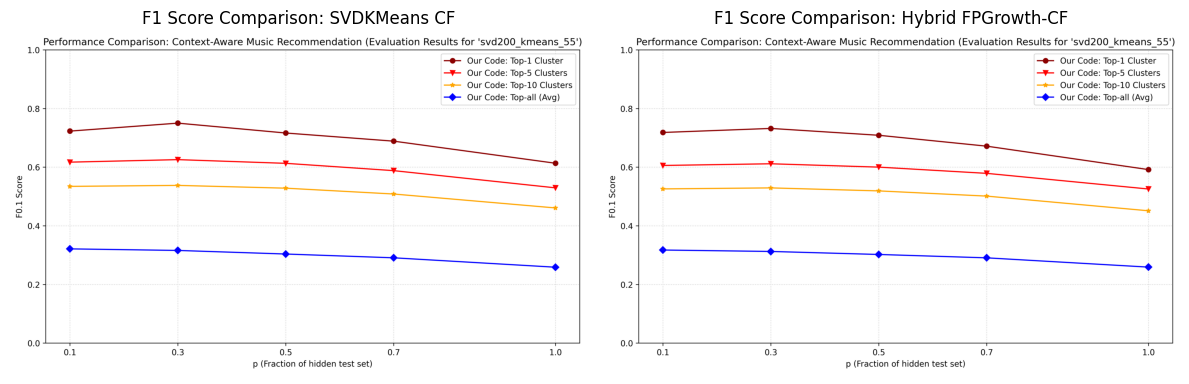

In [5]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Plotting the results
cf_f_score_plot = "clustering/reports/SVDKMeans/svd200_k55_ninit10_maxiter300/f01_comparison.png"
rules_cf_f_score_plot = "evaluation/reports/Hybrid_FPGrowth_CF/f01_comparison.png"
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

ax[0].imshow(mpimg.imread(cf_f_score_plot))
ax[0].set_title("F1 Score Comparison: SVDKMeans CF")
ax[0].axis('off')

ax[1].imshow(mpimg.imread(rules_cf_f_score_plot))
ax[1].set_title("F1 Score Comparison: Hybrid FPGrowth-CF")
ax[1].axis('off')

plt.tight_layout()
plt.show()

In [6]:
# Better more detailed viewing
hybrid_txt = "evaluation/reports/Hybrid_FPGrowth_CF/evaluation_metrics_svd200_kmeans_55.txt"
pure_cf_txt = "clustering/reports/SVDKMeans/svd200_k55_ninit10_maxiter300/evaluation_metrics_svd200_kmeans_55.txt"

if os.path.exists(pure_cf_txt) and os.path.exists(hybrid_txt):
    flat_df, table = compare_results(pure_cf_txt, hybrid_txt)
    display(table)
else:
    print("Check your file paths; one or both reports are missing.")

#### Structural Trade-offs in Recommendation Precision (interpretation of CF vs. Rules + CF)
A comparative analysis of the F0.1 scores across varying metric depths ($p$) reveals a marginal, yet systematic, performance reduction in the hybrid model compared to the pure collaborative filtering (CF) baseline. As evidenced in the **Delta** values, the integration of FP-Growth association rules resulted in a consistent decrease in F0.1 scores for the **Top-1** and **Top-5** cluster tiers, with the most pronounced deficit occuring at $p = 1.0$ for the Top-1 cluster ($-0.0216$). 

#### Aforementioned "Album Effect" and Retrieval Diversity


The high Jaccard similarity and Lift metrics observed in the rule mining phase (reaching up to 20.0+ in some clusters) indicate that the FP-Growth component predominantly captures intra-album associations or "perfectly" correlated track sequences. While these rules provide high precision for navigational or structured listering patterns, their dominance at the top of the ranked list limits the retrieval capabilities of the CF model. 

The data confirms this through the metric detph decay, as $p$ increases, the hybrid model's deficit typically grows. This suggests that while rules are effective for immediate, high-confidence "next-track" prediction, they are less capable of populating a broader, diverse recommendation set compared to the SVDKMeans baseline. 

#### Top-all Convergence
Despite the precision trade-offs in localized high-performing clusters, the Top-all (average) demonstrate significant robustness. The Delta for the aggregate average remains negligible (oscillating between $-0.0039$ and $+0.0003$), indicating that the hybrid approach maintains the baseline's generalizability across the entire dataset. 

Notably, at $p = 1.0$ for the "Top-all" category, the hybrid model achieves a positive Delta ($+0.0003$). This convergence suggests that the inclusion of association rules may marginally enhance Recall in broader, more heterogeneous clusters where latent similarity signals are weaker, thereby compensating for the precision loss in "homogenous" or highly structured clusters, but the signal is too weak for making any conclusions. 

The results indicate that while the hybrid FP-Growth-CF architecture introduced a robust mechanism for rule-based interpretability, it requires careful calibration of the rule-to-CF injection ratio. 

### 

In [8]:
# el muchacho betterino
eval(df=df,
     cluster_col=svd_kmeans_cluster_col, 
     unique_texts=unique_texts, 
     tfidf_matrix=tfidf_matrix, 
     output_dir=hybrid_output_dir+"/refine_results",
     rule_generator=fp_generator,
     refine_results=True, 
)

Saving evaluation results to: evaluation/reports/Hybrid_FPGrowth_CF/refine_results/

CALCULATING SILHOUETTE SCORE

CALCULATING SILHOUETTE SCORE FOR svd200_kmeans_55
-> Final Silhouette Score (svd200_kmeans_55): 0.1148

Processing Cluster 32.0...
Number of samples in Cluster 32.0: 2849225
  -> Successfully split 11016 users into train/test sets.
  -> Sub-sampling to 200 users (out of 11016)...
  -> Mining association rules for cluster 32.0...
[FP-Growth | Cluster 32.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 32.0] Loaded 0 rules from cache in 0.00 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 12.0...
Number of samples in Cluster 12.0: 598278
  -> Successfully split 6266 users into train/test sets.
  -> Sub-sampling to 200 users (out of 6266)...
  -> Mining association rules for cluster 12.0...
[FP-Growth | Cluster 12.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 12.0] Loaded 0 rules from cache in 0.00 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 2.0...
Number of samples in Cluster 2.0: 181794
  -> Successfully split 3129 users into train/test sets.
  -> Sub-sampling to 200 users (out of 3129)...
  -> Mining association rules for cluster 2.0...
[FP-Growth | Cluster 2.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 2.0] Loaded 100 rules from cache in 0.00 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 4.0...
Number of samples in Cluster 4.0: 178788
  -> Successfully split 685 users into train/test sets.
  -> Sub-sampling to 200 users (out of 685)...
  -> Mining association rules for cluster 4.0...
[FP-Growth | Cluster 4.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 4.0] Loaded 941 rules from cache in 0.01 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 6.0...
Number of samples in Cluster 6.0: 166844
  -> Successfully split 1557 users into train/test sets.
  -> Sub-sampling to 200 users (out of 1557)...
  -> Mining association rules for cluster 6.0...
[FP-Growth | Cluster 6.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 6.0] Loaded 1719 rules from cache in 0.02 seconds.
  -> Generating recommendations & evaluating 200 sampled users...


...


Processing Cluster 3.0...
Number of samples in Cluster 3.0: 47082
  -> Successfully split 586 users into train/test sets.
  -> Sub-sampling to 200 users (out of 586)...
  -> Mining association rules for cluster 3.0...
[FP-Growth | Cluster 3.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 3.0] Loaded 26 rules from cache in 0.00 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 10.0...
Number of samples in Cluster 10.0: 46939
  -> Successfully split 816 users into train/test sets.
  -> Sub-sampling to 200 users (out of 816)...
  -> Mining association rules for cluster 10.0...
[FP-Growth | Cluster 10.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 10.0] Loaded 14 rules from cache in 0.00 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 11.0...
Number of samples in Cluster 11.0: 46093
  -> Successfully split 688 users into train/test sets.
  -> Sub-sampling to 200 users (out of 688)...
  -> Mining association rules for cluster 11.0...
[FP-Growth | Cluster 11.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 11.0] Loaded 1594 rules from cache in 0.02 seconds.
  -> Generating recommendations & evaluating 200 sampled users...



Processing Cluster 7.0...
Number of samples in Cluster 7.0: 44501
  -> Successfully split 706 users into train/test sets.
  -> Sub-sampling to 200 users (out of 706)...
  -> Mining association rules for cluster 7.0...
[FP-Growth | Cluster 7.0] Found cached rules! Loading from CSV...
[FP-Growth | Cluster 7.0] Loaded 39344 rules from cache in 0.34 seconds.
  -> Generating recommendations & evaluating 200 sampled users...


KeyboardInterrupt: 